In [ ]:
!pip install kaggle

Load kaggle dataset

In [ ]:
!kaggle datasets download -d pratsharma7/the-american-express-campus-challenge-dataset

Dataset URL: https://www.kaggle.com/datasets/pratsharma7/the-american-express-campus-challenge-dataset
License(s): MIT
100% 111M/111M [00:01<00:00, 65.0MB/s]



Unzipping the dataset

In [ ]:
!unzip the-american-express-campus-challenge-dataset.zip

Archive:  the-american-express-campus-challenge-dataset.zip
  inflating: amex_data.csv           
  inflating: data_dictionary.xlsx    
  inflating: submission_template.csv  


Read the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("amex_data.csv")
df.head()

,customer_id,offer_id,event_ts,event_dt,offer_action,var_1,var_2,var_3,var_4,var_5,...,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50
0,1010494,601711,2023-11-01 10:25:21.000904,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.089583,0.083204,2151.0,0.0,0.0,0.0,0.0,0.0,True,0.0
1,1010494,33452,2023-11-09 08:37:35.165000,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.111752,0.181776,1668.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1010494,88456737,2023-11-01 10:15:55.000489,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.088514,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1010494,390981,2023-11-01 10:27:27.000313,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.086931,0.059246,3678.0,0.0,False,0.0,0.0,0.0,1.0,0.0
4,1010494,7114,2023-11-09 08:37:38.553000,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.089497,0.124221,3619.0,0.0,0.0,0.0,False,0.0,1.0,0.0


Task 2


 i) Handling of Missing Values


In [ ]:
import pandas as pd
import numpy as np

# Standardize target variable
def clean_target(val):
    if val in [1, '1', 'True', True]:
        return 1
    return 0

df['offer_action'] = df['offer_action'].apply(clean_target)

# Impute missing values with 0
df = df.fillna(0)

print("Target distribution after cleaning:")
print(df['offer_action'].value_counts())

Target distribution after cleaning:
offer_action
0    1870424
1     134388
Name: count, dtype: int64


ii) Identification and Removal of Duplicates


In [ ]:
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)
print(f"Removed {initial_count - final_count} duplicate rows.")

Removed 25032 duplicate rows.


 iii) Detection and Handling of Outliers


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['customer_id', 'offer_id', 'offer_action'])

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outlier clipping completed for numeric features.")

Outlier clipping completed for numeric features.


iv) Encoding of Categorical Variables


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
object_cols = ['var_45', 'var_46', 'var_47', 'var_49', 'var_50']

for col in object_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical encoding completed.")

Categorical encoding completed.


3) Feature Engineering


In [ ]:
df['event_ts'] = pd.to_datetime(df['event_ts'], format='mixed')
df['event_hour'] = df['event_ts'].dt.hour
df['is_weekend'] = df['event_ts'].dt.dayofweek.isin([5, 6]).astype(int)

print("Engineered Features: event_hour, is_weekend")
display(df[['event_ts', 'event_hour', 'is_weekend']].head())

Engineered Features: event_hour, is_weekend


,event_ts,event_hour,is_weekend
0,2023-11-01 10:25:21.000904,10,0
1,2023-11-09 08:37:35.165000,8,0
2,2023-11-01 10:15:55.000489,10,0
3,2023-11-01 10:27:27.000313,10,0
4,2023-11-09 08:37:38.553000,8,0


Task 3 - Exploratory Data Analysis & Visualisation



i) Identification of Key Patterns



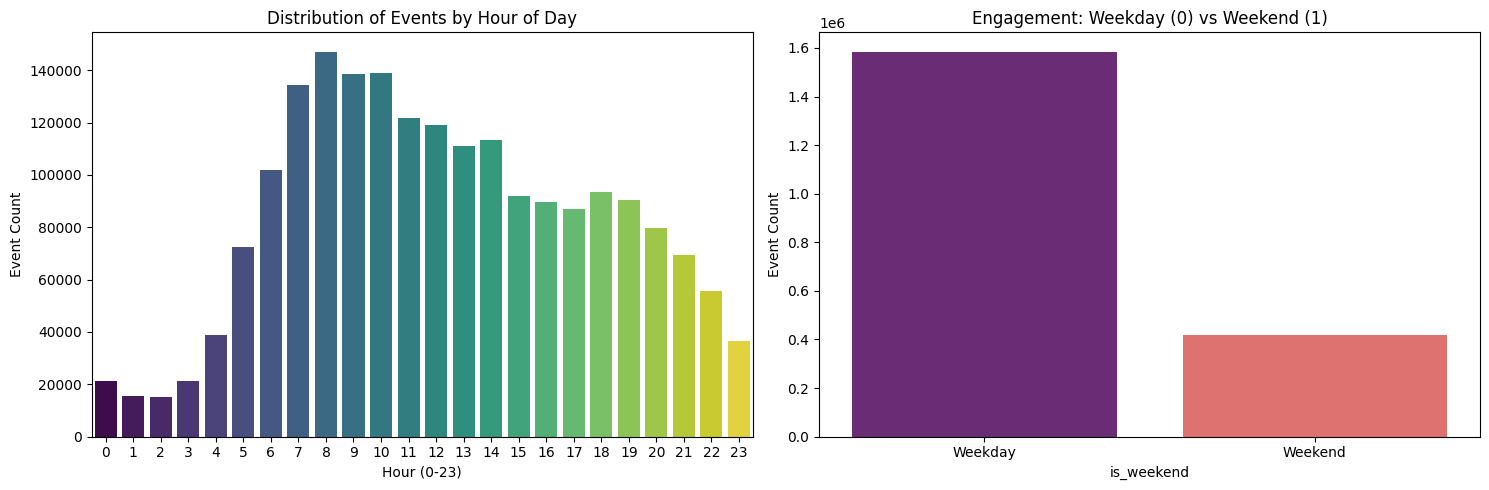

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

if not os.path.exists('amex_data.csv'):
    !unzip -o the-american-express-campus-challenge-dataset.zip

df = pd.read_csv('amex_data.csv')

def clean_target(val):
    if val in [1, '1', 'True', True]: return 1
    return 0
df['offer_action'] = df['offer_action'].apply(clean_target)
df['event_ts'] = pd.to_datetime(df['event_ts'], format='mixed')
df['event_hour'] = df['event_ts'].dt.hour
df['is_weekend'] = df['event_ts'].dt.dayofweek.isin([5, 6]).astype(int)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='event_hour', palette='viridis', hue='event_hour', legend=False)
plt.title('Distribution of Events by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Event Count')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='is_weekend', palette='magma', hue='is_weekend', legend=False)
plt.title('Engagement: Weekday (0) vs Weekend (1)')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel('Event Count')
plt.tight_layout()
plt.show()

ii) Detection of Outliers



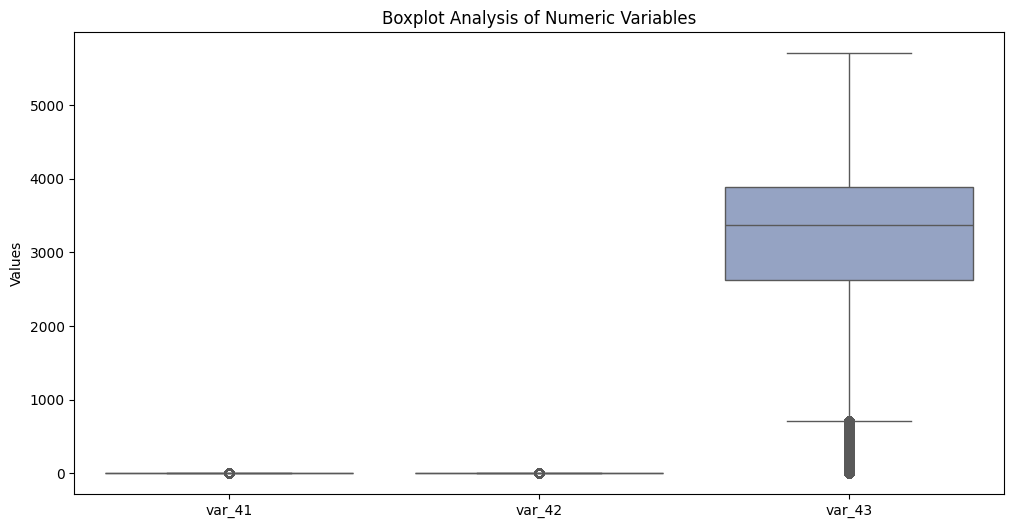

In [ ]:
plt.figure(figsize=(12, 6))
sample_vars = ['var_41', 'var_42', 'var_43']
sns.boxplot(data=df[sample_vars].fillna(0), palette='Set2')
plt.title('Boxplot Analysis of Numeric Variables')
plt.ylabel('Values')
plt.show()

iii) Correlation and Relationships


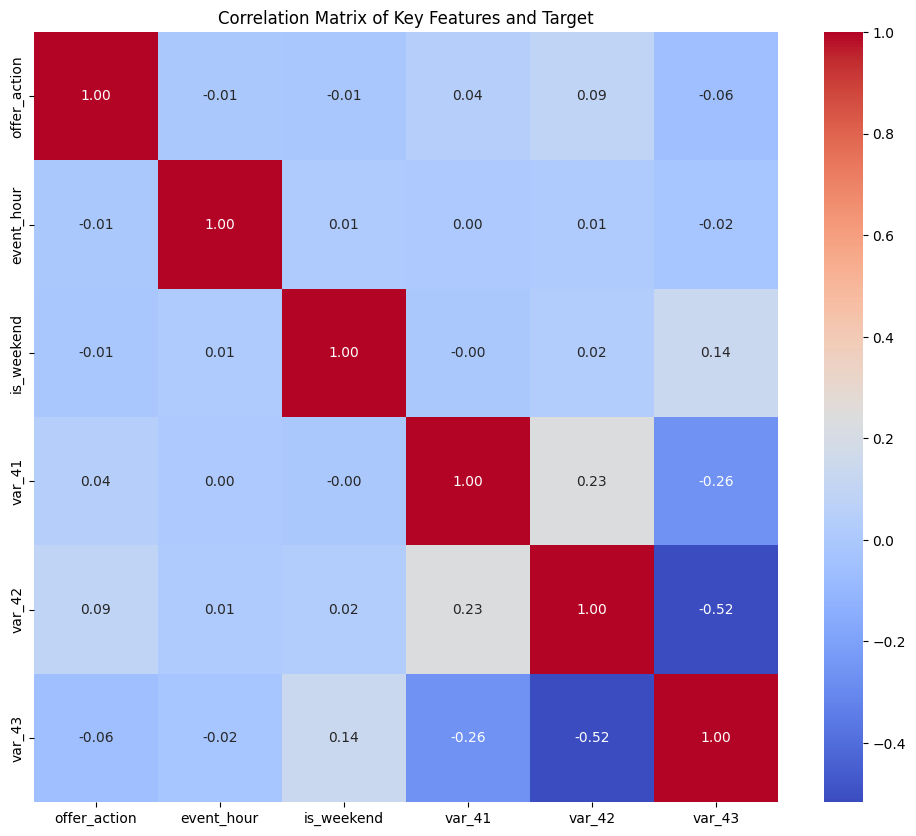

In [ ]:
plt.figure(figsize=(12, 10))
corr_cols = ['offer_action', 'event_hour', 'is_weekend', 'var_41', 'var_42', 'var_43']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Features and Target')
plt.show()

 iv) Data Imbalance or Bias Discussion



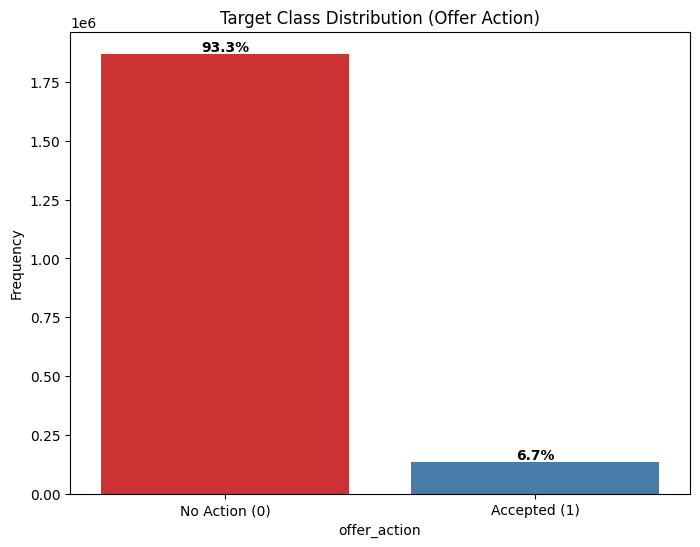

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='offer_action', palette='Set1', hue='offer_action', legend=False)
plt.title('Target Class Distribution (Offer Action)')
plt.xticks([0, 1], ['No Action (0)', 'Accepted (1)'])
plt.ylabel('Frequency')

total = len(df)
for i, val in enumerate(df['offer_action'].value_counts().sort_index()):
    plt.text(i, val + 10000, f'{val/total:.1%}', ha='center', fontweight='bold')
plt.show()

 Task 4: Modelling & Evaluation



 ii) Data Splitting Strategy



In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ensure all features are numeric for scikit-learn compatibility
X = df.drop(columns=['offer_action', 'customer_id', 'offer_id', 'event_ts', 'event_dt'], errors='ignore').copy()

# Convert boolean or object types that might contain strings like 'True'/'False' to numeric
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'bool':
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

y = df['offer_action']

# Final safeguard against missing values
X = X.fillna(0)

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Positive class in Test Set: {y_test.mean():.2%}")

Training set shape: (1603849, 52)
Test set shape: (400963, 52)
Positive class in Test Set: 6.70%


iii) Model Training



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import os

# Reload data if not in memory
if 'df' not in locals():
    if not os.path.exists('amex_data.csv'):
        !unzip -o the-american-express-campus-challenge-dataset.zip
    df = pd.read_csv('amex_data.csv')

# Standardize target for modeling
def clean_target(val):
    if val in [1, '1', 'True', True]: return 1

    return 0
df['offer_action'] = df['offer_action'].apply(clean_target)

# Feature preparation
X = df.drop(columns=['offer_action', 'customer_id', 'offer_id', 'event_ts', 'event_dt'], errors='ignore').copy()
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'bool':
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

y = df['offer_action']
X = X.fillna(0)

# Perform Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features (Crucial for Logistic Regression convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Train models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1) # Reduced estimators for speed

print("Training Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train) # RF doesn't strictly need scaling

print("Model training complete.")

Training Logistic Regression...
Training Random Forest...
Model training complete.


 iv) Evaluation Metrics


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

def evaluate_model(model, X_t, y_t, name):
    preds = model.predict(X_t)
    probs = model.predict_proba(X_t)[:, 1]

    print(f"--- {name} Evaluation ---")
    print(classification_report(y_t, preds))
    print(f"ROC-AUC: {roc_auc_score(y_t, probs):.4f}")
    print(f"PR-AUC: {average_precision_score(y_t, probs):.4f}\n")

evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
evaluate_model(rf_model, X_test, y_test, "Random Forest")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95    374085
           1       0.22      0.12      0.16     26878

    accuracy                           0.91    400963
   macro avg       0.58      0.55      0.56    400963
weighted avg       0.89      0.91      0.90    400963

ROC-AUC: 0.5946
PR-AUC: 0.1069

--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.97    374085
           1       0.91      0.01      0.03     26878

    accuracy                           0.93    400963
   macro avg       0.92      0.51      0.50    400963
weighted avg       0.93      0.93      0.90    400963

ROC-AUC: 0.7651
PR-AUC: 0.2834



v) Model Comparison and Visualization



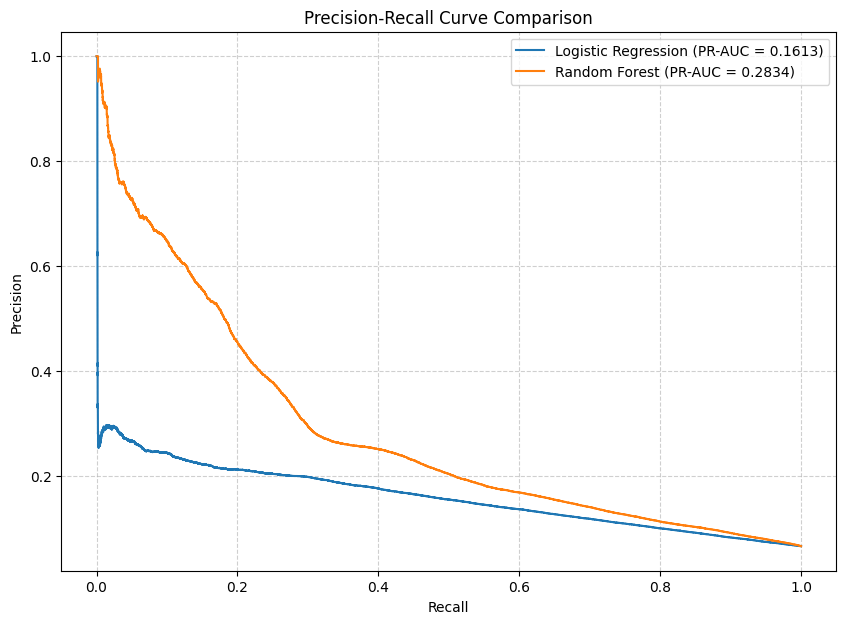

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

def plot_pr_curve(model, X_val, y_val, name, is_scaled=False):
    # Use scaled data for Logistic Regression if required
    probs = model.predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.figure(figsize=(10, 7))
# Logistic Regression needs the scaled test set
plot_pr_curve(lr_model, X_test_scaled, y_test, "Logistic Regression")
# Random Forest uses the original test set
plot_pr_curve(rf_model, X_test, y_test, "Random Forest")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()